In [1]:
import os

files = os.listdir("../data/external/glenda_enid/endometriosis")

print(files[:10])

['enid_0.jpg', 'enid_1.jpg', 'enid_10.jpg', 'enid_100.jpg', 'enid_101.jpg', 'enid_102.jpg', 'enid_103.jpg', 'enid_104.jpg', 'enid_105.jpg', 'enid_106.jpg']


In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import random_split
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(torch.__version__)

2.7.1+cpu


In [4]:
import sys

print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [7]:
import sys

print(sys.executable)

f:\Projects\endometriosis-ai\venv\Scripts\python.exe


In [2]:
import torch

print(torch.__version__)

2.7.1+cpu


In [4]:
from torchvision import datasets
from torchvision import transforms
from torchvision import models

print("TorchVision OK")

TorchVision OK


In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [6]:
print(torch.cuda.is_available())

False


In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(
    root="../data/external/glenda_enid",
    transform=transform
)

print("Total Images:", len(dataset))
print("Classes:", dataset.classes)

Total Images: 1022
Classes: ['endometriosis', 'no_endometriosis']


In [8]:
total_size = len(dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 715
Validation: 153
Test: 154


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoaders created")

DataLoaders created


In [10]:
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    2
)

model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\samee/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 27.9MB/s]


Linear(in_features=2048, out_features=2, bias=True)


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Ready for training")

Ready for training


In [12]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [13]:
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

In [14]:
num_epochs = 5

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs}"
        f" | Train Loss: {train_loss:.4f}"
        f" | Train Acc: {train_acc:.4f}"
        f" | Val Loss: {val_loss:.4f}"
        f" | Val Acc: {val_acc:.4f}"
    )

Epoch 1/5 | Train Loss: 0.6035 | Train Acc: 0.7189 | Val Loss: 0.3901 | Val Acc: 0.8824
Epoch 2/5 | Train Loss: 0.2845 | Train Acc: 0.9301 | Val Loss: 0.1465 | Val Acc: 0.9477
Epoch 3/5 | Train Loss: 0.1353 | Train Acc: 0.9538 | Val Loss: 0.1678 | Val Acc: 0.9346
Epoch 4/5 | Train Loss: 0.0542 | Train Acc: 0.9916 | Val Loss: 0.0849 | Val Acc: 0.9673
Epoch 5/5 | Train Loss: 0.0325 | Train Acc: 0.9944 | Val Loss: 0.0484 | Val Acc: 0.9935


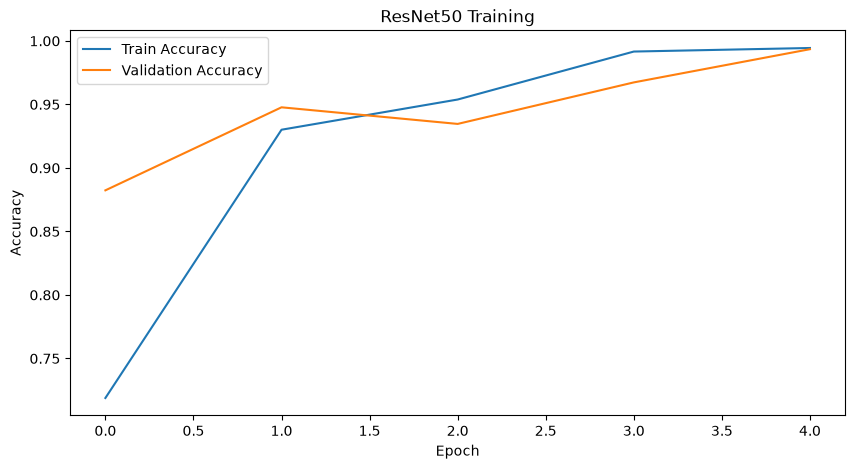

In [22]:
plt.figure(figsize=(10,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.title("ResNet50 Training")
plt.savefig("../docs/figures/glenda_training_curve.png")
plt.show()

In [16]:
print("Best Validation Accuracy:", max(val_accs))

Best Validation Accuracy: 0.9934640522875817


In [17]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [18]:
print(
    "Test Accuracy:",
    accuracy_score(
        all_labels,
        all_preds
    )
)

Test Accuracy: 0.9545454545454546


In [19]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=dataset.classes
    )
)

                  precision    recall  f1-score   support

   endometriosis       0.95      0.96      0.96        83
no_endometriosis       0.96      0.94      0.95        71

        accuracy                           0.95       154
       macro avg       0.95      0.95      0.95       154
    weighted avg       0.95      0.95      0.95       154



In [20]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

[[80  3]
 [ 4 67]]


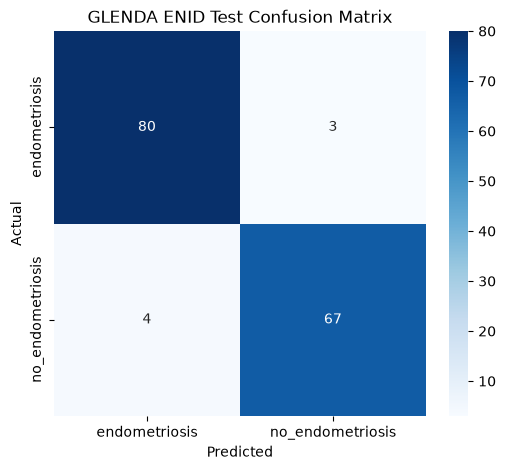

In [21]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("GLENDA ENID Test Confusion Matrix")

plt.savefig(
    "../docs/figures/glenda_confusion_matrix.png"
)

plt.show()

In [23]:
torch.save(
    model.state_dict(),
    "../models/glenda_resnet50.pth"
)